# 03 - Clusterizacao de Produtos e Classificacao ABC

Objetivo: classificar produtos em grupos A/B/C de acordo com potencial comercial, usando receita, volume, frequencia, cobertura geografica, crescimento recente e estabilidade de demanda.

A classificacao ABC deste notebook nao e apenas uma curva de Pareto tradicional. Ela combina:

- ranking de receita;
- ranking de unidades vendidas;
- frequencia de venda;
- crescimento recente;
- estabilidade da demanda;
- clusterizacao para identificar perfis similares de produtos.

A saida esperada e uma tabela priorizada para orientar sortimento, estoque, campanhas e recomendacoes no dashboard.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "product_sales_dataset.csv"
DATA_PATH

WindowsPath('C:/Users/vinicius/Documents/Projetos/Product_sales_analysis/data/raw/product_sales_dataset.csv')

## 2. Carga e preparo da base

In [2]:
df = pd.read_csv(DATA_PATH)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
for col in ["Price_USD", "Quantity_Sold", "Total_Sales_USD"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Product_Name", "Category", "Order_Date", "Price_USD", "Quantity_Sold", "Total_Sales_USD"])
df["Year_Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()

df.head()

,Product_ID,Product_Name,Category,Price_USD,Quantity_Sold,Total_Sales_USD,Order_Date,Customer_City,Year_Month
0,1001,Lipstick,Beauty,26,7,182,2025-01-24,Karachi,2025-01-01
1,1002,Jacket,Fashion,254,6,1524,2026-04-01,Peshawar,2026-04-01
2,1003,Gym Gloves,Sports,30,10,300,2025-11-05,Peshawar,2025-11-01
3,1004,History Book,Books,45,6,270,2026-01-05,Lahore,2026-01-01
4,1005,Tennis Ball,Sports,401,1,401,2025-11-28,Quetta,2025-11-01


In [3]:
summary = pd.Series({
    "rows": len(df),
    "products": df["Product_Name"].nunique(),
    "categories": df["Category"].nunique(),
    "cities": df["Customer_City"].nunique(),
    "min_order_date": df["Order_Date"].min().date(),
    "max_order_date": df["Order_Date"].max().date(),
})
summary

rows                    1000
products                  24
categories                 6
cities                     5
min_order_date    2025-01-02
max_order_date    2026-05-16
dtype: object

## 3. Features por produto

Criamos features que representam tamanho comercial, frequencia, cobertura, crescimento e risco operacional.

- `revenue`: receita total do produto.
- `units`: unidades vendidas.
- `orders`: numero de linhas/pedidos.
- `active_months`: meses com venda.
- `cities`: cidades onde o produto vendeu.
- `recent_growth_pct`: crescimento dos ultimos 3 meses completos contra os 3 meses anteriores.
- `demand_cv`: coeficiente de variacao mensal; quanto menor, mais previsivel.

In [4]:
monthly_product = (
    df.groupby(["Product_Name", "Year_Month"], as_index=False)
    .agg(
        monthly_revenue=("Total_Sales_USD", "sum"),
        monthly_units=("Quantity_Sold", "sum"),
        monthly_orders=("Product_ID", "count"),
    )
)

product_base = (
    df.groupby("Product_Name", as_index=False)
    .agg(
        category=("Category", lambda x: x.mode().iloc[0]),
        revenue=("Total_Sales_USD", "sum"),
        units=("Quantity_Sold", "sum"),
        orders=("Product_ID", "count"),
        avg_price=("Price_USD", "mean"),
        avg_ticket=("Total_Sales_USD", "mean"),
        cities=("Customer_City", "nunique"),
        first_sale=("Order_Date", "min"),
        last_sale=("Order_Date", "max"),
    )
)

monthly_stats = (
    monthly_product.groupby("Product_Name", as_index=False)
    .agg(
        active_months=("Year_Month", "nunique"),
        monthly_revenue_mean=("monthly_revenue", "mean"),
        monthly_revenue_std=("monthly_revenue", "std"),
        monthly_units_mean=("monthly_units", "mean"),
    )
)

last_month = df["Year_Month"].max()
recent_start = last_month - pd.DateOffset(months=2)
previous_start = recent_start - pd.DateOffset(months=3)
previous_end = recent_start - pd.DateOffset(months=1)

recent = (
    monthly_product[monthly_product["Year_Month"].between(recent_start, last_month)]
    .groupby("Product_Name", as_index=False)["monthly_revenue"].sum()
    .rename(columns={"monthly_revenue": "revenue_last_3m"})
)
previous = (
    monthly_product[monthly_product["Year_Month"].between(previous_start, previous_end)]
    .groupby("Product_Name", as_index=False)["monthly_revenue"].sum()
    .rename(columns={"monthly_revenue": "revenue_prev_3m"})
)

product_features = (
    product_base.merge(monthly_stats, on="Product_Name", how="left")
    .merge(recent, on="Product_Name", how="left")
    .merge(previous, on="Product_Name", how="left")
)

product_features[["revenue_last_3m", "revenue_prev_3m", "monthly_revenue_std"]] = product_features[["revenue_last_3m", "revenue_prev_3m", "monthly_revenue_std"]].fillna(0)
product_features["demand_cv"] = np.where(
    product_features["monthly_revenue_mean"] > 0,
    product_features["monthly_revenue_std"] / product_features["monthly_revenue_mean"],
    0,
)
product_features["recent_growth_pct"] = np.where(
    product_features["revenue_prev_3m"] > 0,
    (product_features["revenue_last_3m"] / product_features["revenue_prev_3m"] - 1) * 100,
    0,
)
product_features["recency_days"] = (df["Order_Date"].max() - product_features["last_sale"]).dt.days

product_features.head()

,Product_Name,category,revenue,units,orders,avg_price,avg_ticket,cities,first_sale,last_sale,active_months,monthly_revenue_mean,monthly_revenue_std,monthly_units_mean,revenue_last_3m,revenue_prev_3m,demand_cv,recent_growth_pct,recency_days
0,Chair,Home,44994,174,31,255.71,"1,451.42",5,2025-01-09,2026-04-30,15,"2,999.60","2,030.56",11.60,6212,10510,0.68,-40.89,16
1,Coffee Mug,Home,59260,245,41,239.07,"1,445.37",5,2025-01-17,2026-04-13,16,"3,703.75","3,480.62",15.31,14410,6760,0.94,113.17,33
2,Cricket Bat,Sports,66331,252,47,266.09,"1,411.30",5,2025-01-21,2026-05-14,16,"4,145.69","3,542.51",15.75,7102,4306,0.85,64.93,2
3,Face Wash,Beauty,70936,258,46,270.33,"1,542.09",5,2025-01-05,2026-05-15,17,"4,172.71","3,056.49",15.18,14657,8518,0.73,72.07,1
4,Football,Sports,67989,243,42,288.40,"1,618.79",5,2025-01-07,2026-05-11,17,"3,999.35","2,683.08",14.29,13936,16787,0.67,-16.98,5


## 4. ABC tradicional por receita

Esta e a classificacao ABC classica: produtos A acumulam aproximadamente 80% da receita, B vao ate 95% e C representam a cauda final.

In [5]:
abc_revenue = product_features.sort_values("revenue", ascending=False).copy()
abc_revenue["revenue_share_pct"] = abc_revenue["revenue"] / abc_revenue["revenue"].sum() * 100
abc_revenue["revenue_cum_pct"] = abc_revenue["revenue_share_pct"].cumsum()
abc_revenue["abc_revenue_class"] = np.select(
    [abc_revenue["revenue_cum_pct"] <= 80, abc_revenue["revenue_cum_pct"] <= 95],
    ["A", "B"],
    default="C",
)

abc_revenue[["Product_Name", "category", "revenue", "units", "revenue_share_pct", "revenue_cum_pct", "abc_revenue_class"]].head(20)

,Product_Name,category,revenue,units,revenue_share_pct,revenue_cum_pct,abc_revenue_class
22,Tennis Ball,Sports,96227,330,7.02,7.02,A
5,Gym Gloves,Sports,80127,281,5.84,12.86,A
21,Table,Home,74455,283,5.43,18.29,A
12,Lipstick,Beauty,72172,256,5.26,23.56,A
3,Face Wash,Beauty,70936,258,5.17,28.73,A
4,Football,Sports,67989,243,4.96,33.69,A
2,Cricket Bat,Sports,66331,252,4.84,38.53,A
9,Jeans,Fashion,65260,240,4.76,43.29,A
1,Coffee Mug,Home,59260,245,4.32,47.61,A
19,Smart Watch,Electronics,59069,196,4.31,51.92,A


In [6]:
abc_summary = (
    abc_revenue.groupby("abc_revenue_class", as_index=False)
    .agg(
        products=("Product_Name", "count"),
        revenue=("revenue", "sum"),
        units=("units", "sum"),
    )
)
abc_summary["revenue_share_pct"] = abc_summary["revenue"] / abc_summary["revenue"].sum() * 100
abc_summary

,abc_revenue_class,products,revenue,units,revenue_share_pct
0,A,17,1078139,4119,78.64
1,B,4,185891,808,13.56
2,C,3,107002,528,7.80


## 5. Score de potencial comercial

Para uma visao mais util ao analista de produtos, criamos um score ponderado. Ele combina receita, unidades, frequencia, cobertura e crescimento. A instabilidade da demanda entra como penalidade.

Pesos usados:

- receita: 40%;
- unidades: 25%;
- frequencia de pedidos: 15%;
- cobertura geografica: 10%;
- crescimento recente: 10%;
- penalidade de volatilidade: ate 10%.

In [7]:
score_cols = ["revenue", "units", "orders", "cities", "recent_growth_pct"]
scaler = MinMaxScaler()
score_scaled = pd.DataFrame(
    scaler.fit_transform(product_features[score_cols]),
    columns=[f"score_{col}" for col in score_cols],
    index=product_features.index,
)

volatility_scaled = MinMaxScaler().fit_transform(product_features[["demand_cv"]]).ravel()

product_scored = pd.concat([product_features, score_scaled], axis=1)
product_scored["potential_score"] = (
    0.40 * product_scored["score_revenue"]
    + 0.25 * product_scored["score_units"]
    + 0.15 * product_scored["score_orders"]
    + 0.10 * product_scored["score_cities"]
    + 0.10 * product_scored["score_recent_growth_pct"]
    - 0.10 * volatility_scaled
)
product_scored["potential_score"] = MinMaxScaler().fit_transform(product_scored[["potential_score"]]).ravel() * 100

product_scored = product_scored.merge(
    abc_revenue[["Product_Name", "abc_revenue_class", "revenue_share_pct", "revenue_cum_pct"]],
    on="Product_Name",
    how="left",
)

product_scored.sort_values("potential_score", ascending=False).head(10)

,Product_Name,category,revenue,units,orders,avg_price,avg_ticket,cities,first_sale,last_sale,active_months,monthly_revenue_mean,monthly_revenue_std,monthly_units_mean,revenue_last_3m,revenue_prev_3m,demand_cv,recent_growth_pct,recency_days,score_revenue,score_units,score_orders,score_cities,score_recent_growth_pct,potential_score,abc_revenue_class,revenue_share_pct,revenue_cum_pct
22,Tennis Ball,Sports,96227,330,56,284.79,"1,718.34",5,2025-01-02,2026-05-14,15,"6,415.13","3,929.68",22.00,7795,16843,0.61,-53.72,2,1.00,1.00,1.00,0.00,0.15,100.00,A,7.02,7.02
21,Table,Home,74455,283,46,255.61,"1,618.59",5,2025-01-28,2026-05-16,15,"4,963.67","4,035.14",18.87,19442,12532,0.81,55.14,0,0.69,0.74,0.62,0.00,0.67,71.75,A,5.43,18.29
3,Face Wash,Beauty,70936,258,46,270.33,"1,542.09",5,2025-01-05,2026-05-15,17,"4,172.71","3,056.49",15.18,14657,8518,0.73,72.07,1,0.64,0.61,0.62,0.00,0.75,68.47,A,5.17,28.73
5,Gym Gloves,Sports,80127,281,51,275.63,"1,571.12",5,2025-02-09,2026-05-02,16,"5,007.94","5,243.17",17.56,3080,7805,1.05,-60.54,14,0.77,0.73,0.81,0.00,0.12,65.86,A,5.84,12.86
12,Lipstick,Beauty,72172,256,49,275.49,"1,472.90",5,2025-01-10,2026-05-10,16,"4,510.75","3,507.43",16.00,8912,14650,0.78,-39.17,6,0.66,0.60,0.73,0.00,0.22,63.56,A,5.26,23.56
2,Cricket Bat,Sports,66331,252,47,266.09,"1,411.30",5,2025-01-21,2026-05-14,16,"4,145.69","3,542.51",15.75,7102,4306,0.85,64.93,2,0.58,0.58,0.65,0.00,0.72,61.43,A,4.84,38.53
4,Football,Sports,67989,243,42,288.40,"1,618.79",5,2025-01-07,2026-05-11,17,"3,999.35","2,683.08",14.29,13936,16787,0.67,-16.98,5,0.60,0.53,0.46,0.00,0.33,57.99,A,4.96,33.69
17,Shampoo,Beauty,55690,234,45,249.42,"1,237.56",5,2025-01-11,2026-05-04,16,"3,480.62","2,670.00",14.62,11621,5576,0.77,108.41,12,0.43,0.48,0.58,0.00,0.92,54.82,A,4.06,55.98
1,Coffee Mug,Home,59260,245,41,239.07,"1,445.37",5,2025-01-17,2026-04-13,16,"3,703.75","3,480.62",15.31,14410,6760,0.94,113.17,33,0.48,0.54,0.42,0.00,0.95,51.88,A,4.32,47.61
9,Jeans,Fashion,65260,240,43,269.98,"1,517.67",5,2025-01-07,2026-05-09,17,"3,838.82","3,539.59",14.12,14551,20883,0.92,-30.32,7,0.56,0.51,0.50,0.00,0.27,48.87,A,4.76,43.29


## 6. Clusterizacao de produtos

Usaremos K-Means para encontrar 3 perfis de produtos. Depois, os clusters sao mapeados para A/B/C pela media do `potential_score`.

Importante: aqui A/B/C representa potencial comercial relativo, nao apenas Pareto de receita.

In [8]:
cluster_features = [
    "revenue", "units", "orders", "avg_price", "avg_ticket", "cities",
    "active_months", "recent_growth_pct", "demand_cv", "recency_days",
]

X = product_scored[cluster_features].replace([np.inf, -np.inf], 0).fillna(0)
X_scaled = StandardScaler().fit_transform(X)

k_results = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
    })

k_results = pd.DataFrame(k_results)
k_results

  File "C:\Users\vinicius\Documents\Projetos\Product_sales_analysis\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette
0,2,151.83,0.24
1,3,124.33,0.22
2,4,104.07,0.19
3,5,89.80,0.19
4,6,75.10,0.19


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
product_scored["cluster"] = kmeans.fit_predict(X_scaled)

cluster_rank = (
    product_scored.groupby("cluster", as_index=False)
    .agg(
        avg_potential_score=("potential_score", "mean"),
        avg_revenue=("revenue", "mean"),
        products=("Product_Name", "count"),
    )
    .sort_values("avg_potential_score", ascending=False)
)
cluster_rank["abc_cluster_class"] = ["A", "B", "C"]

product_scored = product_scored.merge(cluster_rank[["cluster", "abc_cluster_class"]], on="cluster", how="left")
cluster_rank

,cluster,avg_potential_score,avg_revenue,products,abc_cluster_class
0,0,67.24,"74,187.12",8,A
1,1,39.47,"51,950.50",8,B
2,2,30.35,"45,241.38",8,C


## 7. Classificacao ABC final

A classe final prioriza o `potential_score`, pois ele representa melhor a ideia de potencial de venda/receita do que apenas receita acumulada.

Regra:

- A: top 30% dos produtos por potencial.
- B: proximos 40%.
- C: ultimos 30%.

Como temos apenas 24 produtos, essa regra evita uma classe A grande demais ou uma classe C pequena demais.

In [10]:
final_ranking = product_scored.sort_values("potential_score", ascending=False).reset_index(drop=True)
final_ranking["rank"] = np.arange(1, len(final_ranking) + 1)
final_ranking["rank_pct"] = final_ranking["rank"] / len(final_ranking)
final_ranking["abc_potential_class"] = np.select(
    [final_ranking["rank_pct"] <= 0.30, final_ranking["rank_pct"] <= 0.70],
    ["A", "B"],
    default="C",
)

final_cols = [
    "rank", "Product_Name", "category", "abc_potential_class", "abc_cluster_class", "abc_revenue_class",
    "potential_score", "revenue", "units", "orders", "avg_ticket", "cities", "active_months",
    "recent_growth_pct", "demand_cv", "recency_days", "revenue_share_pct", "revenue_cum_pct",
]

final_ranking[final_cols]

,rank,Product_Name,category,abc_potential_class,abc_cluster_class,abc_revenue_class,potential_score,revenue,units,orders,avg_ticket,cities,active_months,recent_growth_pct,demand_cv,recency_days,revenue_share_pct,revenue_cum_pct
0,1,Tennis Ball,Sports,A,A,A,100.00,96227,330,56,"1,718.34",5,15,-53.72,0.61,2,7.02,7.02
1,2,Table,Home,A,A,A,71.75,74455,283,46,"1,618.59",5,15,55.14,0.81,0,5.43,18.29
2,3,Face Wash,Beauty,A,A,A,68.47,70936,258,46,"1,542.09",5,17,72.07,0.73,1,5.17,28.73
3,4,Gym Gloves,Sports,A,A,A,65.86,80127,281,51,"1,571.12",5,16,-60.54,1.05,14,5.84,12.86
4,5,Lipstick,Beauty,A,A,A,63.56,72172,256,49,"1,472.90",5,16,-39.17,0.78,6,5.26,23.56
5,6,Cricket Bat,Sports,A,A,A,61.43,66331,252,47,"1,411.30",5,16,64.93,0.85,2,4.84,38.53
6,7,Football,Sports,A,A,A,57.99,67989,243,42,"1,618.79",5,17,-16.98,0.67,5,4.96,33.69
7,8,Shampoo,Beauty,B,B,A,54.82,55690,234,45,"1,237.56",5,16,108.41,0.77,12,4.06,55.98
8,9,Coffee Mug,Home,B,B,A,51.88,59260,245,41,"1,445.37",5,16,113.17,0.94,33,4.32,47.61
9,10,Jeans,Fashion,B,A,A,48.87,65260,240,43,"1,517.67",5,17,-30.32,0.92,7,4.76,43.29


## 8. Visualizacoes

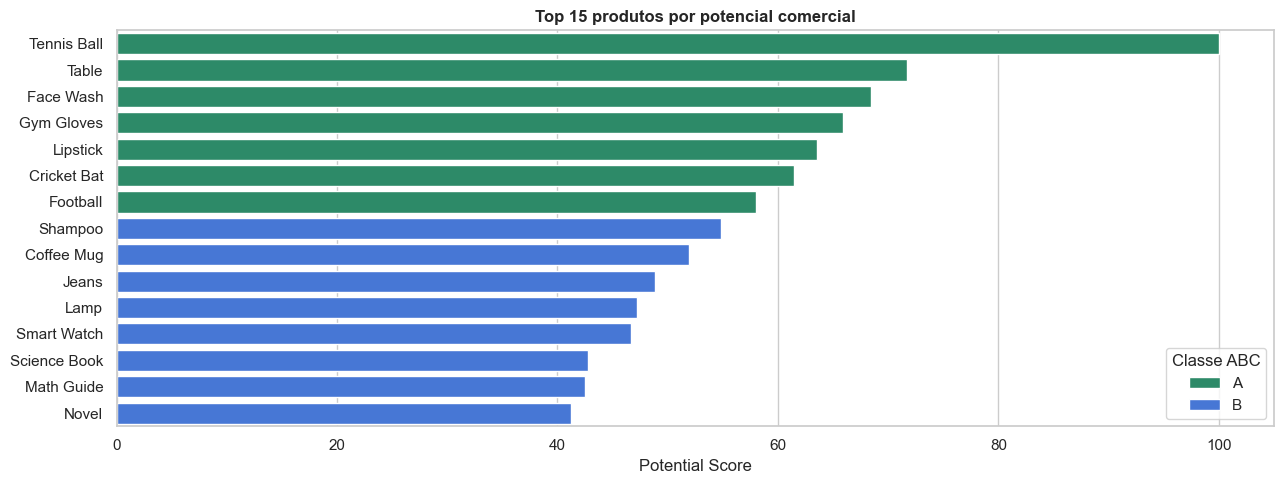

In [11]:
sns.barplot(
    data=final_ranking.head(15),
    y="Product_Name",
    x="potential_score",
    hue="abc_potential_class",
    dodge=False,
    palette={"A": "#1D9A6C", "B": "#2F6FED", "C": "#D84B55"},
)
plt.title("Top 15 produtos por potencial comercial")
plt.xlabel("Potential Score")
plt.ylabel("")
plt.legend(title="Classe ABC")
plt.tight_layout()

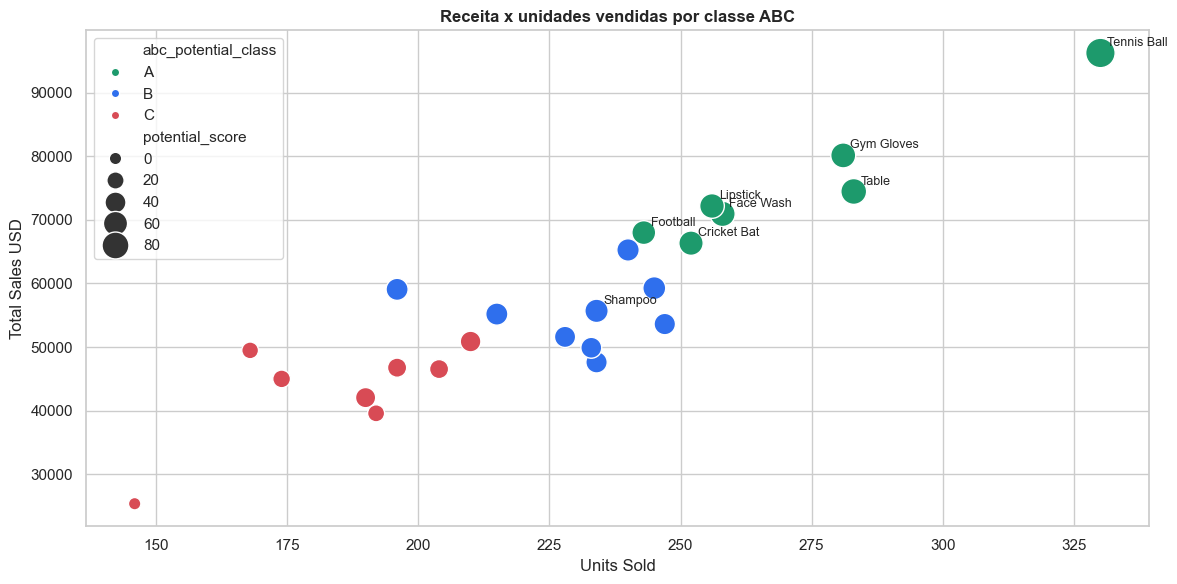

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=final_ranking,
    x="units",
    y="revenue",
    hue="abc_potential_class",
    size="potential_score",
    sizes=(80, 450),
    palette={"A": "#1D9A6C", "B": "#2F6FED", "C": "#D84B55"},
    ax=ax,
)
for _, row in final_ranking.head(8).iterrows():
    ax.annotate(row["Product_Name"], (row["units"], row["revenue"]), fontsize=9, xytext=(5, 5), textcoords="offset points")
plt.title("Receita x unidades vendidas por classe ABC")
plt.xlabel("Units Sold")
plt.ylabel("Total Sales USD")
plt.tight_layout()

In [13]:
class_summary = (
    final_ranking.groupby("abc_potential_class", as_index=False)
    .agg(
        products=("Product_Name", "count"),
        revenue=("revenue", "sum"),
        units=("units", "sum"),
        avg_potential_score=("potential_score", "mean"),
        avg_growth_pct=("recent_growth_pct", "mean"),
        avg_demand_cv=("demand_cv", "mean"),
    )
)
class_summary["revenue_share_pct"] = class_summary["revenue"] / class_summary["revenue"].sum() * 100
class_summary["unit_share_pct"] = class_summary["units"] / class_summary["units"].sum() * 100
class_summary

,abc_potential_class,products,revenue,units,avg_potential_score,avg_growth_pct,avg_demand_cv,revenue_share_pct,unit_share_pct
0,A,7,528237,1903,69.86,3.10,0.79,38.53,34.89
1,B,9,497165,2072,46.16,13.65,0.76,36.26,37.98
2,C,8,345630,1480,24.00,-11.61,0.84,25.21,27.13


## 9. Interpretacao para negocio

- **Classe A**: produtos prioritarios. Devem ter maior atencao em estoque, campanhas, disponibilidade e recomendacoes.
- **Classe B**: produtos de sustentacao. Podem receber acoes segmentadas por cidade/categoria e monitoramento de tendencia.
- **Classe C**: produtos de baixa prioridade relativa. Devem ser avaliados por margem, estrategia de sortimento ou nicho antes de aumentar investimento.

Recomendacao para o dashboard: exibir a classe ABC final, o score de potencial, receita, unidades, crescimento recente e volatilidade. Isso ajuda o analista a diferenciar produto grande, produto emergente e produto arriscado.

## 10. Diagrama da metodologia

O fluxo abaixo resume o que foi avaliado para chegar na clusterizacao e na classificacao ABC final dos produtos.

flowchart LR
    A["1. Dados avaliados<br/>Produto, categoria e cidade<br/>Preco, quantidade e receita<br/>Data do pedido e mes de venda<br/>24 produtos analisados"]
    B["2. Features por produto<br/>Receita total e unidades vendidas<br/>Pedidos, ticket medio e preco medio<br/>Meses ativos e cidades atendidas<br/>Crescimento recente e volatilidade"]
    C["3. ABC tradicional<br/>Ordenacao por receita<br/>Share e receita acumulada<br/>Classes A/B/C por Pareto<br/>Referencia financeira"]
    D["4. Score de potencial<br/>40% receita<br/>25% unidades<br/>15% frequencia de pedidos<br/>10% cobertura geografica<br/>10% crescimento<br/>Penalidade por volatilidade"]
    E["5. Clusterizacao<br/>K-Means com 3 grupos<br/>Features padronizadas<br/>Comparacao por silhouette e inertia<br/>Clusters rankeados pelo score medio"]
    F["6. Saida para negocio<br/>Classe ABC final por potencial comercial<br/>Ranking de produtos prioritarios<br/>Acoes: estoque, campanhas, recomendacao e monitoramento<br/>Campos prontos para integrar ao dashboard"]

    A --> B
    B --> C
    B --> D
    C --> E
    D --> E
    D --> F
    E --> F

**Leitura executiva:** classe A representa maior prioridade comercial; classe B representa sustentacao e oportunidades segmentadas; classe C representa baixa prioridade relativa ou nicho.


## 11. Como os blocos 3, 4 e 5 viram a saida 6

A classificacao final nao depende de uma unica tecnica. Ela combina uma leitura financeira classica, um score de potencial comercial e uma validacao por agrupamento de produtos similares.

### 3. ABC tradicional

O ABC tradicional responde a pergunta: **quais produtos concentram mais receita historica?**

A regra aplicada foi:

- ordenar produtos por `revenue` em ordem decrescente;
- calcular `revenue_share_pct`, a participacao de cada produto na receita total;
- calcular `revenue_cum_pct`, a receita acumulada;
- classificar como:
  - **A**: produtos ate aproximadamente 80% da receita acumulada;
  - **B**: produtos entre 80% e 95%;
  - **C**: produtos restantes.

Essa etapa e importante porque ancora a analise em impacto financeiro real. O limite dela e que receita historica sozinha pode ignorar produtos emergentes, produtos com alto volume, cobertura geografica ou tendencia recente.

### 4. Score de potencial

O score de potencial responde a pergunta: **quais produtos parecem mais promissores para venda, estoque, campanha e recomendacao?**

Para isso, normalizamos as principais variaveis em escala comparavel e calculamos um score ponderado:

- 40% `revenue`: peso principal para impacto financeiro;
- 25% `units`: peso para demanda em volume;
- 15% `orders`: peso para frequencia de compra;
- 10% `cities`: peso para cobertura geografica;
- 10% `recent_growth_pct`: peso para tendencia recente;
- penalidade por `demand_cv`: reduz score de produtos muito volateis.

Esse score transforma varias dimensoes em uma unica medida de potencial comercial. Ele e a principal base do ranking final.

### 5. Clusterizacao

A clusterizacao responde a pergunta: **existem grupos naturais de produtos com comportamento parecido?**

Usamos K-Means com 3 grupos sobre features padronizadas:

- receita;
- unidades;
- pedidos;
- preco medio;
- ticket medio;
- cidades;
- meses ativos;
- crescimento recente;
- volatilidade;
- recencia.

Depois de criar os clusters, cada grupo foi rankeado pela media do `potential_score`:

- cluster com maior score medio vira perfil **A**;
- cluster intermediario vira perfil **B**;
- cluster com menor score medio vira perfil **C**.

A clusterizacao nao substitui o score. Ela funciona como uma validacao comportamental: ajuda a entender se produtos com classificacao parecida tambem possuem padroes comerciais semelhantes.

### 6. Saida final

A saida final combina as tres visoes da seguinte forma:

1. **ABC tradicional** entra como referencia financeira historica (`abc_revenue_class`).
2. **Score de potencial** define o ranking principal e a classe final (`abc_potential_class`).
3. **Clusterizacao** adiciona uma segunda leitura de perfil (`abc_cluster_class`).

A classe final usada para negocio e `abc_potential_class`, porque ela captura melhor a ideia de potencial de vendas/receita do que apenas Pareto historico. As outras duas classificacoes ficam como apoio para interpretacao.

Na pratica:

- produto **A por potencial** deve ser priorizado em estoque, campanhas, recomendacoes e monitoramento;
- se um produto e **A por receita**, mas B/C por potencial, ele pode ser historicamente relevante, mas merece investigacao de tendencia ou volatilidade;
- se um produto e **B/C por receita**, mas A por potencial, ele pode ser emergente ou ter boa oportunidade de crescimento;
- se o cluster diverge da classe final, o analista deve revisar o produto individualmente antes de tomar decisao operacional.
